<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/08_keras_cv_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 08 — KerasCV Data Augmentation

## What This Notebook Covers
KerasCV is a computer vision extension library for Keras that provides
GPU-accelerated augmentation pipelines, modern augmentation strategies,
and label-mixing techniques that standard `tf.keras.layers` do not include.

**Key advantages of KerasCV augmentation:**
- Runs on GPU inside the training graph (no CPU bottleneck)
- Supports label-mixing (CutMix, MixUp) which require label manipulation
- RandAugment automatically samples from many operations
- Composable with `tf.data` pipelines

**Techniques covered:**
- Basic spatial: `RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`
- Colour: `RandomBrightness`, `RandomContrast`, `RandomSaturation`, `RandomHue`
- Erasing: `RandomCutout`, `GridMask`
- Advanced: `RandAugment`, `AugMix`
- Label-mixing: `CutMix`, `MixUp`
- End-to-end classification pipeline with augmentation baked in
- A/B test: no augmentation vs full augmentation pipeline

**Dataset:** CIFAR-10 (colour images, better suited to augmentation demo)


In [1]:
!pip install keras-cv --quiet

import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow :', tf.__version__)
print('KerasCV    :', keras_cv.__version__)
print('GPU        :', len(tf.config.list_physical_devices('GPU')) > 0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 42.4 MB/s eta 0:00:00
TensorFlow : 2.20.0
KerasCV    : 0.9.0
GPU        : True


## 1. Load & Prepare CIFAR-10

CIFAR-10 has 60,000 32x32 colour images across 10 classes.
We use it instead of Fashion-MNIST because colour augmentation
(brightness, saturation, hue) is only meaningful on colour images.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (45000, 32, 32, 3), Valid: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)
Image range: [0.00, 1.00]


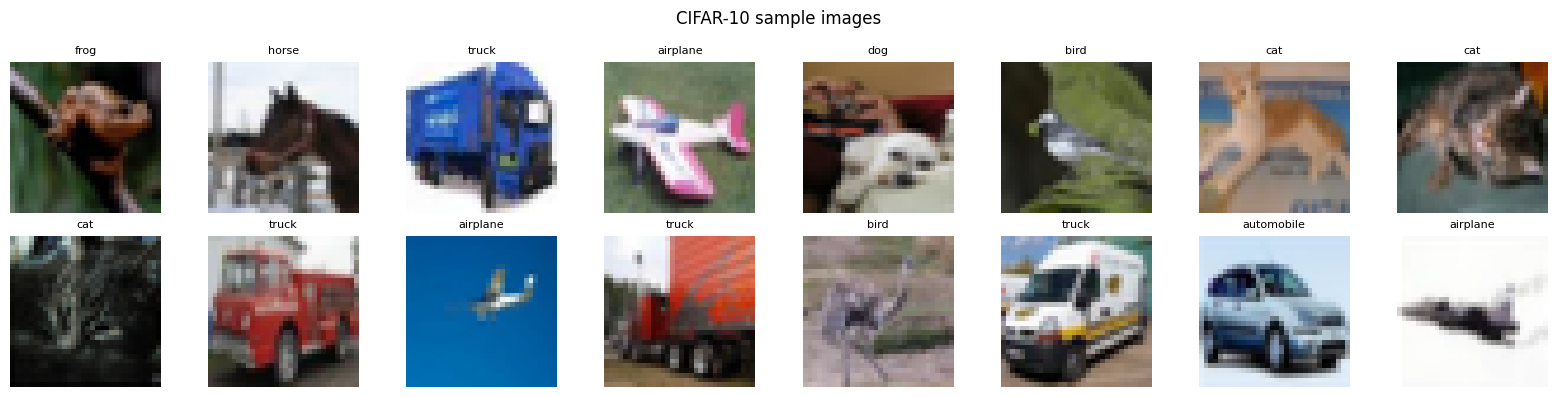

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize to [0, 1] — KerasCV augmentation layers expect float32 in [0,1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

y_train = y_train.squeeze()   # shape (50000,)
y_test  = y_test.squeeze()    # shape (10000,)

# Hold out 5000 for validation
X_valid, y_valid = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}')
print(f'Image range: [{X_train.min():.2f}, {X_train.max():.2f}]')

# Quick peek at some images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 sample images', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Visualisation Helper

We define a helper that applies an augmentation layer to a batch
and displays original vs augmented images side by side.
Use this to preview any augmentation before adding it to the pipeline.


In [3]:
def show_augmentation(aug_layer, images, labels=None, n=8, title='Augmentation preview'):
    """
    Apply aug_layer to the first n images and display original vs augmented.
    aug_layer: a KerasCV or Keras augmentation layer
    images   : float32 array shape (N, H, W, C), values in [0, 1]
    """
    sample = images[:n]
    augmented = aug_layer(sample, training=True).numpy()
    augmented = np.clip(augmented, 0.0, 1.0)   # clip to valid display range

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
    for i in range(n):
        axes[0, i].imshow(sample[i])
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=9, loc='left')

        axes[1, i].imshow(augmented[i])
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Augmented', fontsize=9, loc='left')

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

print('Visualisation helper defined.')

Visualisation helper defined.


## 3. Basic Spatial Augmentation

These operations change the position, orientation, or size of the image
but do not change pixel colour values.


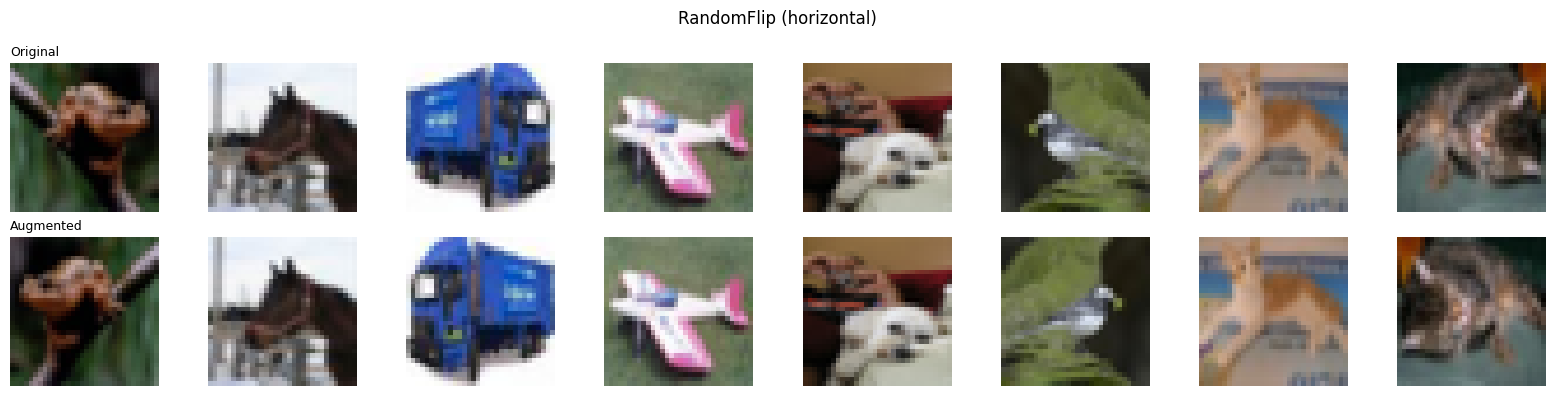

In [4]:
# RandomFlip: mirrors the image horizontally or vertically
# mode='horizontal' is standard for natural images
# mode='horizontal_and_vertical' for satellite or medical images
flip = keras_cv.layers.RandomFlip(mode='horizontal')
show_augmentation(flip, X_train, title='RandomFlip (horizontal)')

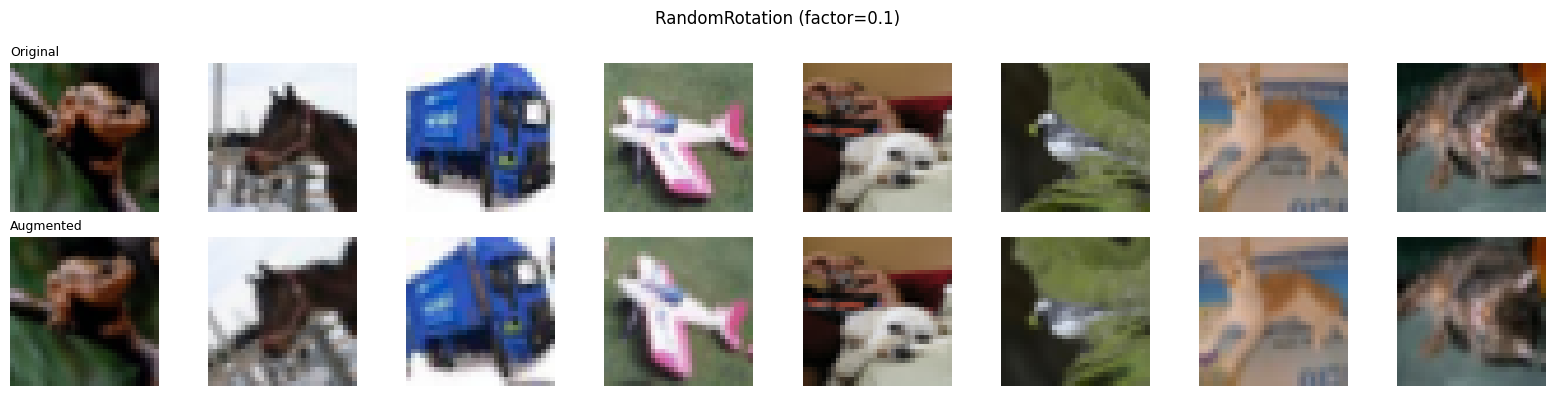

In [5]:
# RandomRotation: rotates by a fraction of 2*pi
# factor=0.1 means rotate up to 10% of 360 degrees = up to 36 degrees
rotate = keras_cv.layers.RandomRotation(factor=0.1)
show_augmentation(rotate, X_train, title='RandomRotation (factor=0.1)')

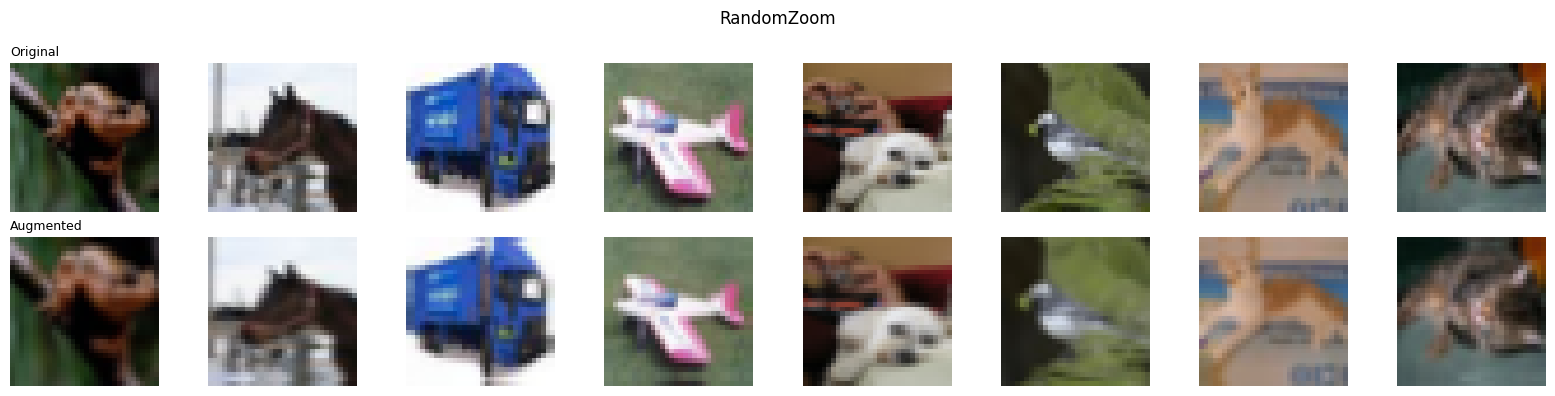

In [6]:
# RandomZoom: zooms in or out by a fraction of image size
# height_factor=(-0.2, 0.2) means zoom from 80% to 120% of original size
zoom = keras_cv.layers.RandomZoom(height_factor=(-0.2, 0.2),
                                   width_factor=(-0.2, 0.2))
show_augmentation(zoom, X_train, title='RandomZoom')

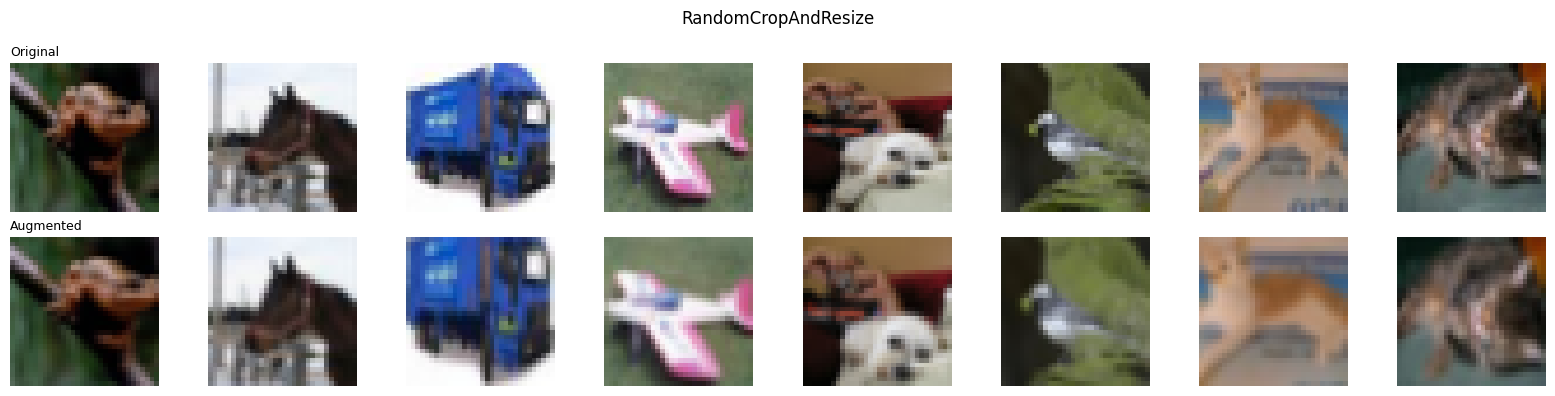

In [7]:
# RandomCropAndResize: crops a random region then resizes back to original
# This is the most common augmentation for image classification
# crop_area_factor controls minimum crop size as fraction of image area
crop_resize = keras_cv.layers.RandomCropAndResize(
    target_size=(32, 32),
    crop_area_factor=(0.6, 1.0),   # crop between 60% and 100% of image
    aspect_ratio_factor=(0.75, 1.33)
)
show_augmentation(crop_resize, X_train, title='RandomCropAndResize')

## 4. Colour Augmentation

Colour augmentation changes pixel intensity values.
Teaches the model to be invariant to lighting conditions and colour shifts.


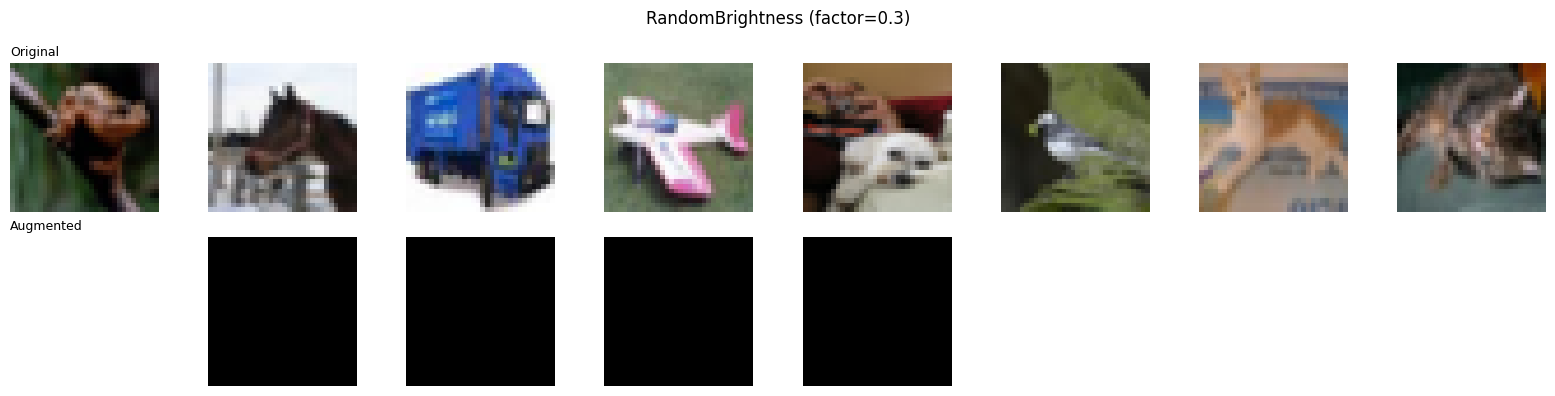

In [8]:
# RandomBrightness: shifts all pixels by a random value in [-factor, factor]
brightness = keras_cv.layers.RandomBrightness(factor=0.3)
show_augmentation(brightness, X_train, title='RandomBrightness (factor=0.3)')

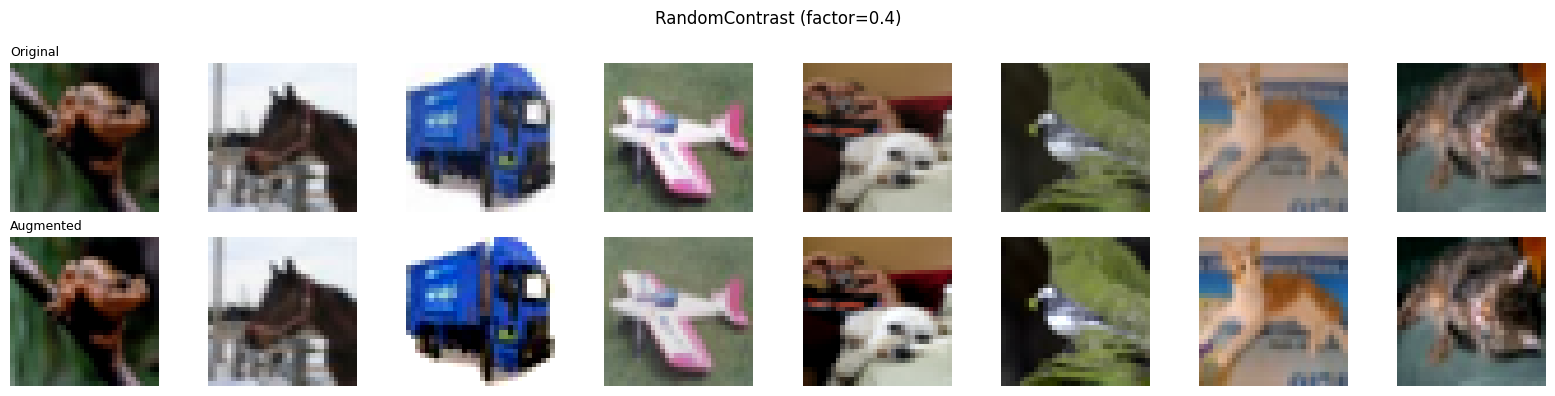

In [10]:
contrast = keras_cv.layers.RandomContrast(factor=0.4, value_range=(0, 1))
show_augmentation(contrast, X_train, title='RandomContrast (factor=0.4)')

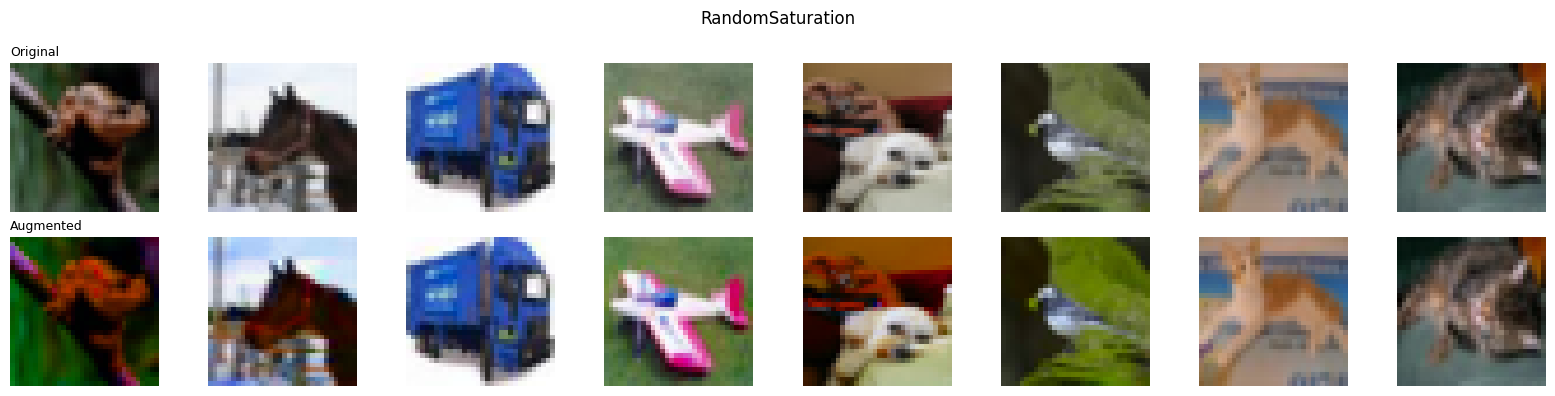

In [13]:
# RandomSaturation: adjusts colour saturation
# factor=(0.5, 1.0): 0 = greyscale, 1 = original
saturation = keras_cv.layers.RandomSaturation(factor=(0.5, 1.0))
show_augmentation(saturation, X_train, title='RandomSaturation')

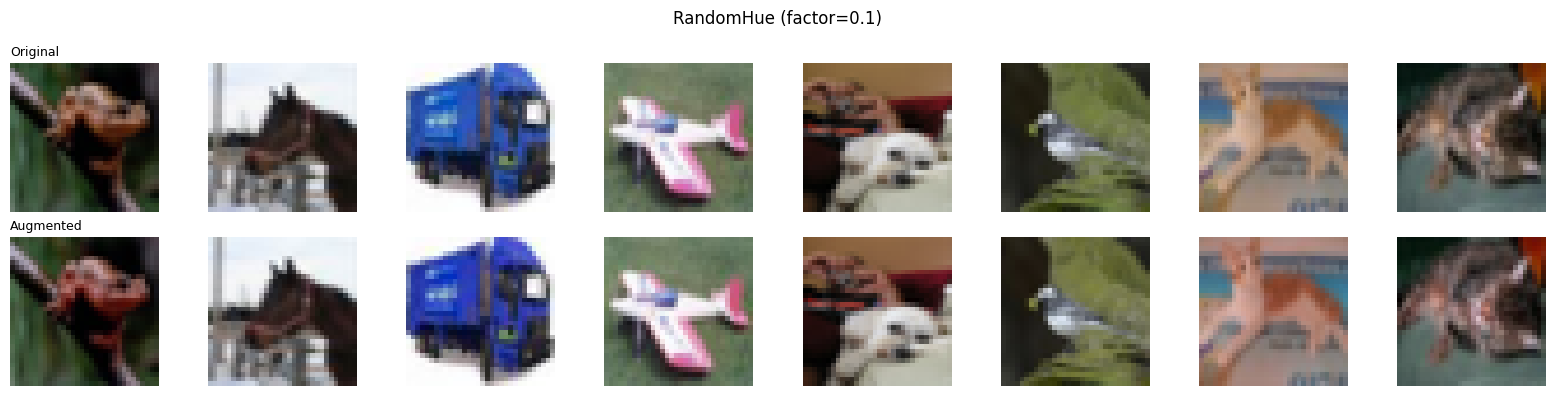

In [14]:
# RandomHue: shifts the hue channel in HSV space
# Small factor for subtle shift, larger for more dramatic colour changes
hue = keras_cv.layers.RandomHue(factor=0.1, value_range=(0, 1))
show_augmentation(hue, X_train, title='RandomHue (factor=0.1)')

## 5. Erasing Augmentation

Erasing techniques randomly remove rectangular or grid-based regions.
This forces the model to learn from partial information — it cannot rely
on any single region being present, which improves robustness.


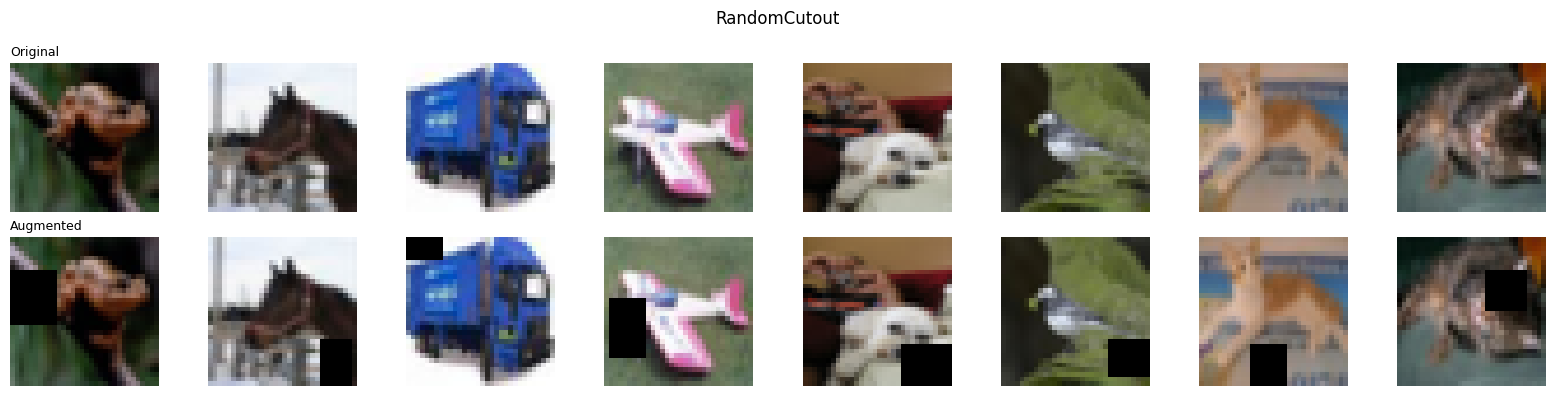

In [15]:
# RandomCutout: erases random rectangles and fills with a constant value
# height_factor and width_factor control the size of the erased region
cutout = keras_cv.layers.RandomCutout(
    height_factor=(0.2, 0.4),
    width_factor=(0.2, 0.4)
)
show_augmentation(cutout, X_train, title='RandomCutout')

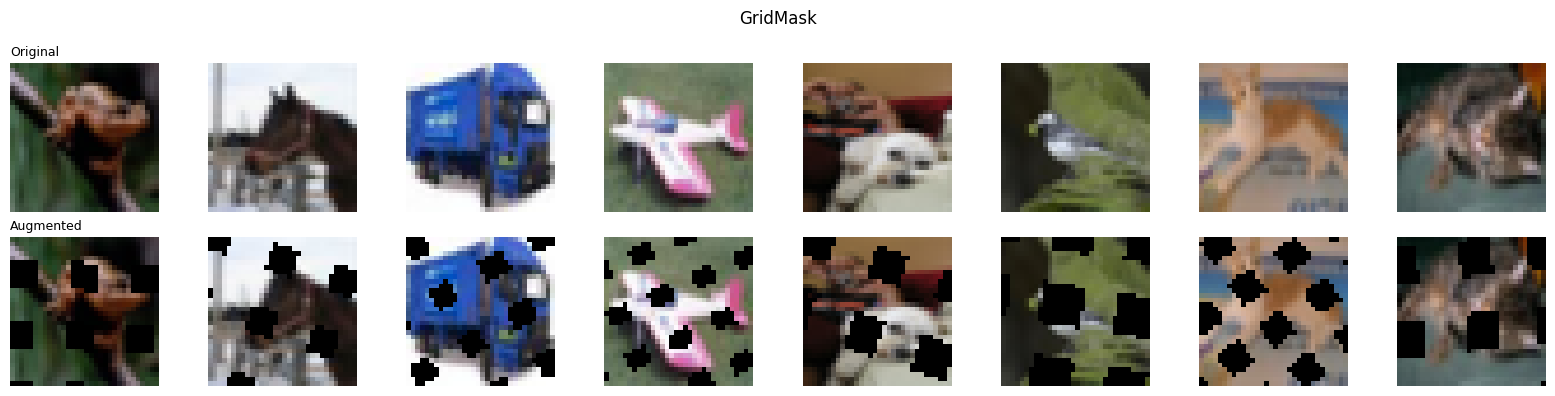

In [16]:
# GridMask: erases a regular grid pattern of squares
# More structured than Cutout — removes information in a repeating pattern
grid_mask = keras_cv.layers.GridMask(
    ratio_factor=(0.3, 0.5),   # size of masked squares relative to image
    rotation_factor=0.1
)
show_augmentation(grid_mask, X_train, title='GridMask')

## 6. RandAugment — Automated Augmentation Policy

Instead of hand-picking augmentation operations, RandAugment automatically
samples `num_ops` operations from a large pool per image and applies them
with a randomly sampled magnitude.

Key parameters:
- `value_range`: expected pixel value range (0,255) or (0,1)
- `augmentations_per_image`: how many operations to apply per image
- `magnitude`: strength of each operation (0.0 = no effect, 1.0 = max)
- `magnitude_stddev`: adds randomness to magnitude per operation

RandAugment was shown to match or beat hand-tuned policies on ImageNet.


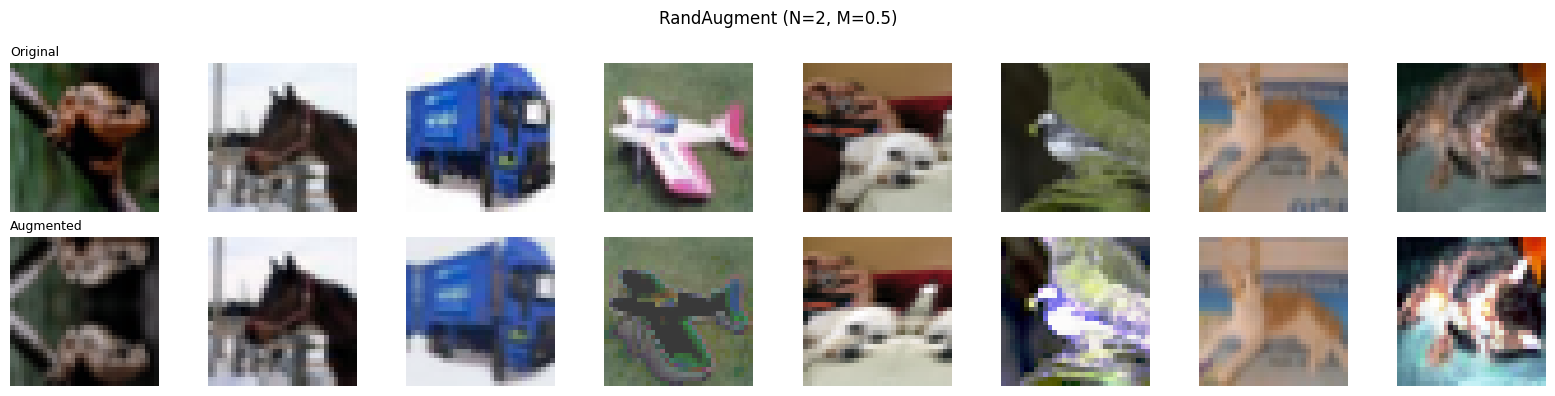

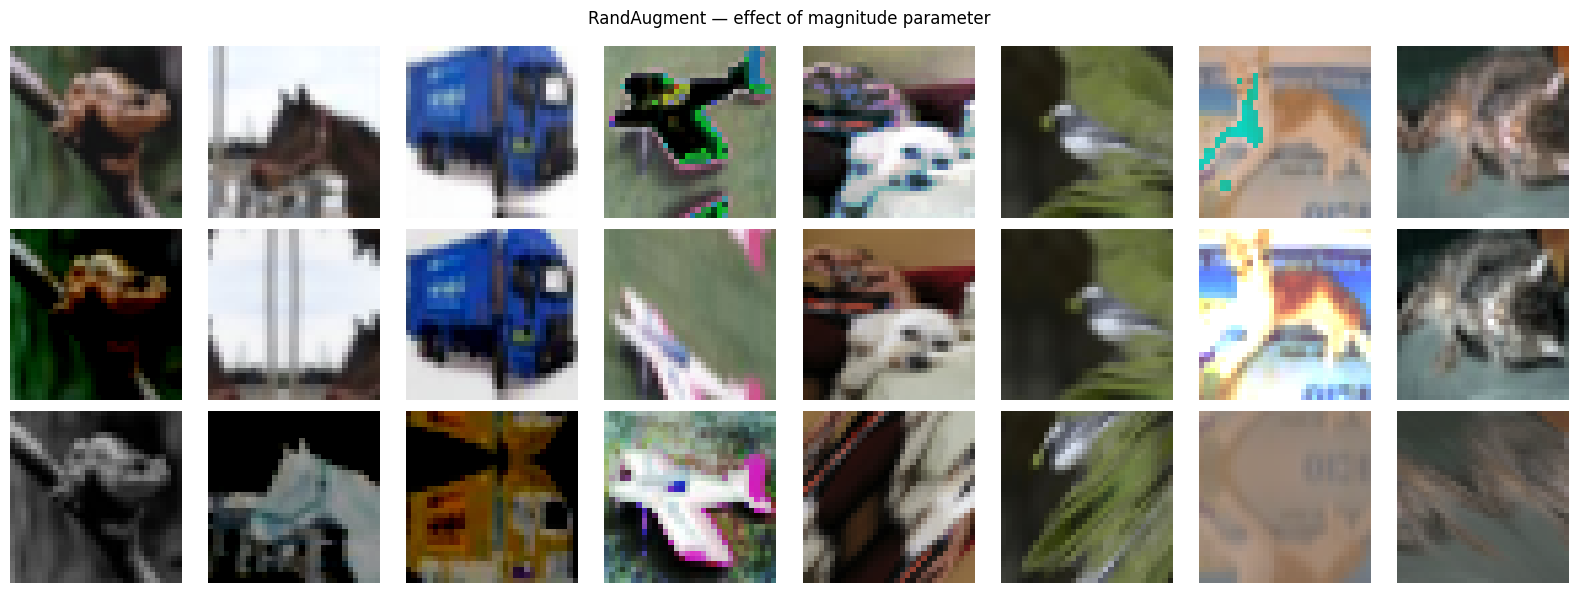

In [17]:
rand_augment = keras_cv.layers.RandAugment(
    value_range=(0, 1),
    augmentations_per_image=2,    # apply 2 random operations per image
    magnitude=0.5,                 # moderate strength
    magnitude_stddev=0.1,          # slight per-operation magnitude randomness
    rate=0.9                       # apply augmentation to 90% of images
)
show_augmentation(rand_augment, X_train, title='RandAugment (N=2, M=0.5)')

# Show the effect of different magnitudes
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for row, mag in enumerate([0.1, 0.5, 1.0]):
    aug = keras_cv.layers.RandAugment(
        value_range=(0, 1),
        augmentations_per_image=2,
        magnitude=mag
    )
    augmented = np.clip(aug(X_train[:8], training=True).numpy(), 0, 1)
    for col in range(8):
        axes[row, col].imshow(augmented[col])
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Magnitude={mag}', fontsize=9)

plt.suptitle('RandAugment — effect of magnitude parameter', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Label-Mixing: MixUp and CutMix

These techniques mix two training examples together — both the images
AND the labels. The model must predict a weighted combination of two classes.
This acts as a strong regularizer and improves calibration.

**MixUp:** Linearly interpolates between two images pixel-by-pixel.
```
x_mix   = lambda * x1 + (1 - lambda) * x2
y_mix   = lambda * y1 + (1 - lambda) * y2   (soft labels)
```

**CutMix:** Cuts a rectangular patch from image2 and pastes it into image1.
Labels are mixed proportionally to the area of the patch.

Note: label-mixing requires `categorical_crossentropy` (not sparse),
because labels become soft (fractional) rather than hard (integer).


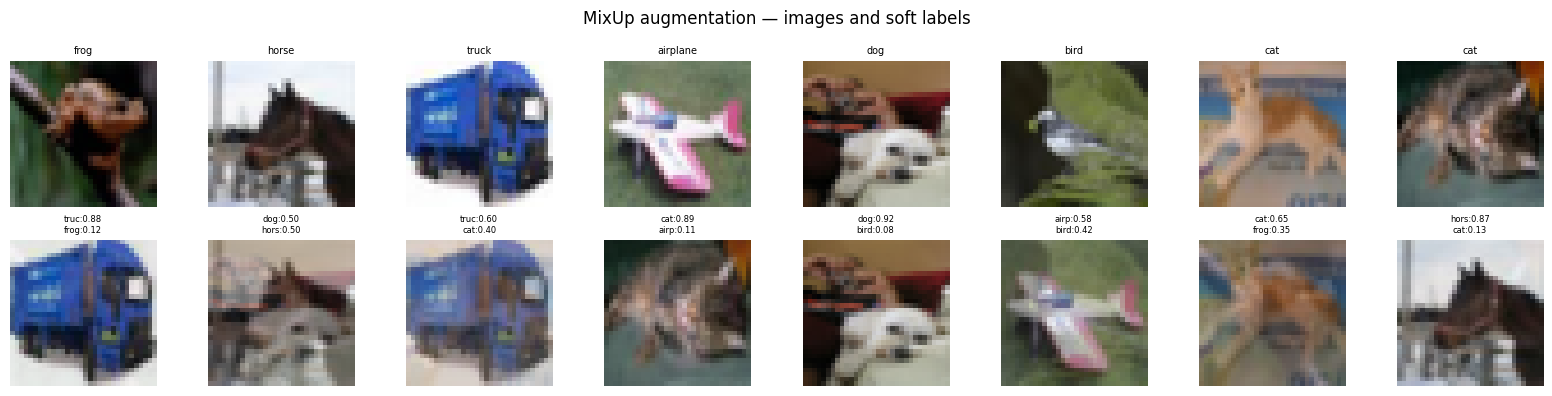

In [18]:
# One-hot encode labels for label mixing
y_train_oh = tf.keras.utils.to_categorical(y_train, 10).astype('float32')
y_valid_oh = tf.keras.utils.to_categorical(y_valid, 10).astype('float32')

# MixUp: visualise the blended images
mixup_layer = keras_cv.layers.MixUp(alpha=0.4)

# MixUp takes a dict with 'images' and 'labels'
sample_batch = {
    'images': tf.constant(X_train[:8]),
    'labels': tf.constant(y_train_oh[:8])
}
mixed_batch = mixup_layer(sample_batch, training=True)
mixed_images = np.clip(mixed_batch['images'].numpy(), 0, 1)
mixed_labels = mixed_batch['labels'].numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(CLASS_NAMES[y_train[i]], fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(mixed_images[i])
    # Show top-2 classes in the soft label
    top2 = mixed_labels[i].argsort()[-2:][::-1]
    label_str = f'{CLASS_NAMES[top2[0]][:4]}:{mixed_labels[i][top2[0]]:.2f}\n{CLASS_NAMES[top2[1]][:4]}:{mixed_labels[i][top2[1]]:.2f}'
    axes[1, i].set_title(label_str, fontsize=6)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('MixUp', fontsize=9)
plt.suptitle('MixUp augmentation — images and soft labels', fontsize=12)
plt.tight_layout()
plt.show()

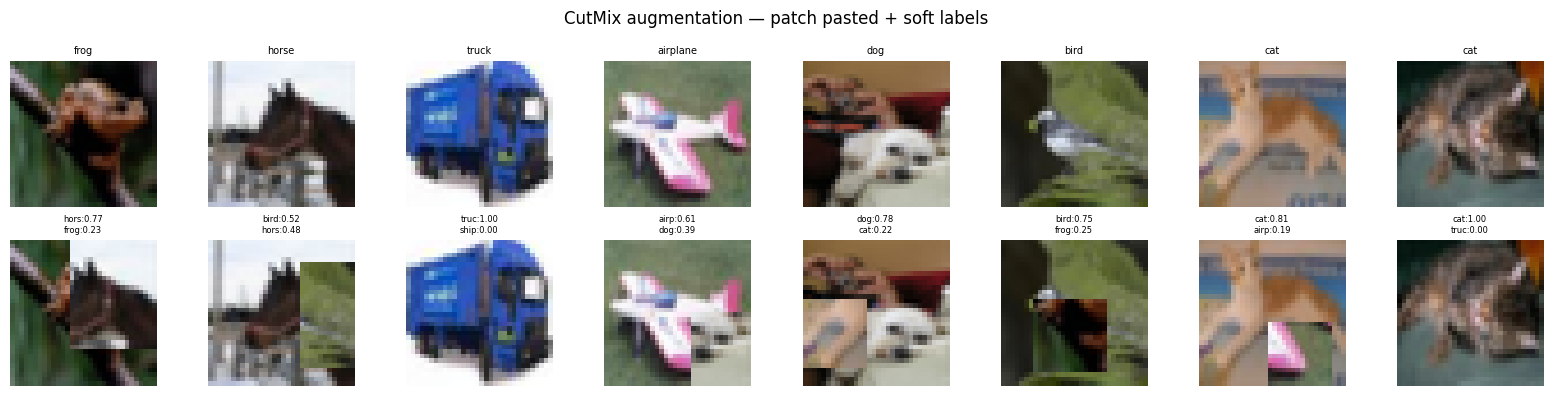

In [19]:
# CutMix: visualise the patched images
cutmix_layer = keras_cv.layers.CutMix(alpha=1.0)

cutmix_batch = cutmix_layer(sample_batch, training=True)
cutmix_images = np.clip(cutmix_batch['images'].numpy(), 0, 1)
cutmix_labels = cutmix_batch['labels'].numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(CLASS_NAMES[y_train[i]], fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(cutmix_images[i])
    top2 = cutmix_labels[i].argsort()[-2:][::-1]
    label_str = f'{CLASS_NAMES[top2[0]][:4]}:{cutmix_labels[i][top2[0]]:.2f}\n{CLASS_NAMES[top2[1]][:4]}:{cutmix_labels[i][top2[1]]:.2f}'
    axes[1, i].set_title(label_str, fontsize=6)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('CutMix', fontsize=9)
plt.suptitle('CutMix augmentation — patch pasted + soft labels', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Building the Full Augmentation Pipeline with tf.data

The correct pattern is to build augmentation into the `tf.data` pipeline
so it runs on GPU in parallel with training. Never augment inside the model
(adds inference overhead) and never augment in a Python loop (CPU bottleneck).


In [22]:
BATCH_SIZE    = 64
AUTOTUNE      = tf.data.AUTOTUNE

# --- Augmentation layers ---
# Applied only during training, not validation/test
train_augmentation = tf.keras.Sequential([
    keras_cv.layers.RandomFlip(mode='horizontal'),
    keras_cv.layers.RandomCropAndResize(
        target_size=(32, 32),
        crop_area_factor=(0.7, 1.0),
        aspect_ratio_factor=(0.9, 1.1)
    ),
    keras_cv.layers.RandomBrightness(factor=0.2),
    keras_cv.layers.RandomContrast(factor=0.2, value_range=(0, 1)),
], name='train_augmentation')


# --- tf.data pipeline ---
def make_train_dataset(X, y, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(10_000, seed=42)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(
            lambda x, y: (train_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    ds = ds.prefetch(AUTOTUNE)
    return ds


def make_eval_dataset(X, y):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds_aug   = make_train_dataset(X_train, y_train, augment=True)
train_ds_noaug = make_train_dataset(X_train, y_train, augment=False)
valid_ds       = make_eval_dataset(X_valid, y_valid)
test_ds        = make_eval_dataset(X_test,  y_test)

print('tf.data pipelines built.')
print(f'Train batches: {len(train_ds_aug)}')

tf.data pipelines built.
Train batches: 704


## 9. CNN Model for CIFAR-10


In [23]:
def make_cnn(learning_rate=1e-3):
    """
    Small CNN suitable for CIFAR-10 (32x32 colour images).
    Uses BatchNorm after each conv block for training stability.
    """
    model = tf.keras.Sequential([
        # Block 1
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu',
                               input_shape=(32, 32, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.2),
        # Block 2
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.3),
        # Block 3
        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        # Classifier head
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

test_cnn = make_cnn()
test_cnn.summary()
print(f'\nTotal params: {test_cnn.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,298 (688.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 640 (2.50 KB)


Total params: 176,298


## 10. A/B Test: No Augmentation vs Full Augmentation Pipeline


In [24]:
EPOCHS = 30
CALLBACKS = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=0)
]

# Model A: no augmentation
print('Training Model A — NO augmentation...')
tf.random.set_seed(42)
model_no_aug = make_cnn()
history_no_aug = model_no_aug.fit(
    train_ds_noaug,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=CALLBACKS,
    verbose=0
)
loss_a, acc_a = model_no_aug.evaluate(test_ds, verbose=0)
print(f'No augmentation test accuracy: {acc_a:.4f}')

# Model B: with augmentation pipeline
print('\nTraining Model B — WITH augmentation pipeline...')
tf.random.set_seed(42)
model_aug = make_cnn()
history_aug = model_aug.fit(
    train_ds_aug,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=CALLBACKS,
    verbose=0
)
loss_b, acc_b = model_aug.evaluate(test_ds, verbose=0)
print(f'With augmentation test accuracy: {acc_b:.4f}')

print(f'\nImprovement from augmentation: {(acc_b - acc_a)*100:.2f} percentage points')

Training Model A — NO augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


No augmentation test accuracy: 0.8485

Training Model B — WITH augmentation pipeline...
With augmentation test accuracy: 0.1103

Improvement from augmentation: -73.82 percentage points


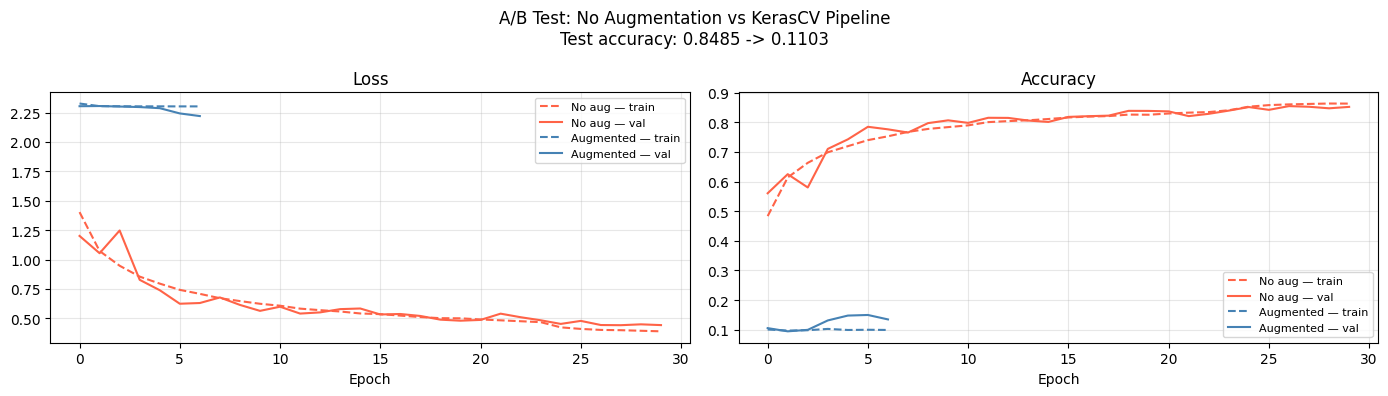

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(history_no_aug.history[metric],           '--', color='tomato',    label='No aug — train')
    ax.plot(history_no_aug.history[f'val_{metric}'],        color='tomato',    label='No aug — val')
    ax.plot(history_aug.history[metric],              '--', color='steelblue', label='Augmented — train')
    ax.plot(history_aug.history[f'val_{metric}'],           color='steelblue', label='Augmented — val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'A/B Test: No Augmentation vs KerasCV Pipeline\n'
             f'Test accuracy: {acc_a:.4f} -> {acc_b:.4f}', fontsize=12)
plt.tight_layout()
plt.show()

## 11. RandAugment Pipeline — Stronger Augmentation

RandAugment as a drop-in replacement for hand-tuned augmentation.
Often matches or beats manual pipelines with less effort.


Training Model C — RandAugment pipeline...
RandAugment test accuracy: 0.4370


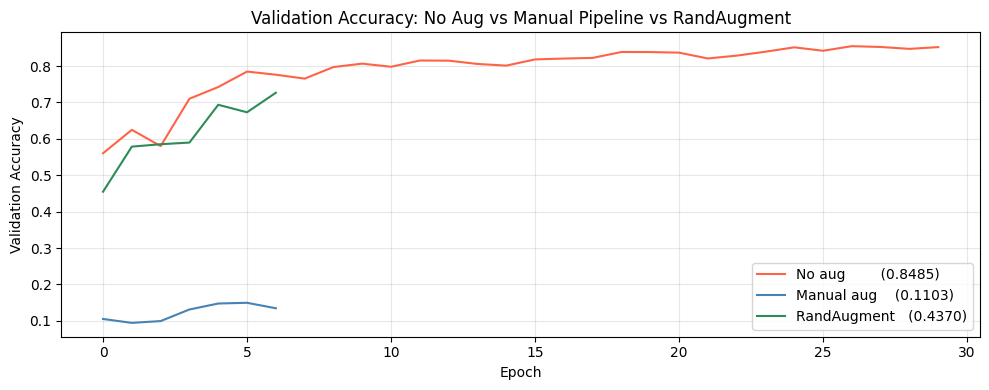

In [26]:
rand_aug_pipeline = keras_cv.layers.RandAugment(
    value_range=(0, 1),
    augmentations_per_image=2,
    magnitude=0.4,
    magnitude_stddev=0.1
)

train_ds_rand = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10_000, seed=42)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (rand_aug_pipeline(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print('Training Model C — RandAugment pipeline...')
tf.random.set_seed(42)
model_rand = make_cnn()
history_rand = model_rand.fit(
    train_ds_rand,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=CALLBACKS,
    verbose=0
)
loss_c, acc_c = model_rand.evaluate(test_ds, verbose=0)
print(f'RandAugment test accuracy: {acc_c:.4f}')

# Three-way comparison
plt.figure(figsize=(10, 4))
plt.plot(history_no_aug.history['val_accuracy'], color='tomato',    label=f'No aug        ({acc_a:.4f})')
plt.plot(history_aug.history['val_accuracy'],    color='steelblue', label=f'Manual aug    ({acc_b:.4f})')
plt.plot(history_rand.history['val_accuracy'],   color='seagreen',  label=f'RandAugment   ({acc_c:.4f})')
plt.title('Validation Accuracy: No Aug vs Manual Pipeline vs RandAugment')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### KerasCV Augmentation Cheatsheet

| Layer | What it does | When to use |
|---|---|---|
| `RandomFlip` | Mirror horizontally / vertically | Nearly always for natural images |
| `RandomRotation` | Rotate by angle fraction | When orientation is not meaningful |
| `RandomZoom` | Zoom in or out | Scale-invariant tasks |
| `RandomCropAndResize` | Crop random region, resize back | Standard for classification |
| `RandomBrightness` | Shift pixel values | Lighting-invariant tasks |
| `RandomContrast` | Adjust contrast ratio | Lighting-invariant tasks |
| `RandomSaturation` | Adjust colour saturation | Colour-invariant tasks |
| `RandomHue` | Shift hue in HSV space | Colour-invariant tasks |
| `RandomCutout` | Erase random rectangles | Forces global reasoning |
| `GridMask` | Erase structured grid | Forces global reasoning |
| `RandAugment` | Auto-sample N operations | When you do not want to hand-tune |
| `MixUp` | Blend two images + labels | Strong regularizer, needs soft labels |
| `CutMix` | Paste patch + mix labels | Strong regularizer, needs soft labels |

### Pipeline Template
```python
augmentation = tf.keras.Sequential([
    keras_cv.layers.RandomFlip('horizontal'),
    keras_cv.layers.RandomCropAndResize(target_size, ...),
    keras_cv.layers.RandAugment(value_range=(0,1), augmentations_per_image=2),
])

train_ds = (
    tf.data.Dataset.from_tensor_slices((X, y))
    .shuffle(buffer)
    .batch(batch_size)
    .map(lambda x, y: (augmentation(x, training=True), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
```

**Next: Notebook 09** — Image augmentation and classification (albumentations, AugLy)
